<a href="https://colab.research.google.com/github/al7arbi-111/pairs-trading-backtester/blob/main/pairs_trading.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import yfinance as yf, pandas as pd, numpy as np

tickers = ["KO", "PEP", "XOM", "CVX", "V", "MA", "HD", "LOW", "GS", "MS"]
prices = yf.download(tickers, start="2019-01-01", end="2026-01-01")["Close"].dropna()
print(prices.shape)
print(prices.tail(3))


/tmp/ipykernel_1661/1107929820.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(tickers, start="2019-01-01", end="2026-01-01")["Close"].dropna()
[*********************100%***********************]  10 of 10 completed


(1760, 10)
Ticker             CVX          GS          HD         KO         LOW  \
Date                                                                    
2025-12-29  146.888229  879.308472  340.066956  68.823212  240.096390   
2025-12-30  148.172363  871.660400  338.990356  68.734917  239.456329   
2025-12-31  148.269653  866.318604  336.788147  68.577972  237.467270   

Ticker              MA          MS         PEP           V         XOM  
Date                                                                    
2025-12-29  575.079285  177.022461  139.978928  352.493286  118.159645  
2025-12-30  574.601624  176.176407  139.901291  351.509186  118.610596  
2025-12-31  568.093567  174.651535  139.280197  348.616577  117.973373  


In [2]:
from statsmodels.tsa.stattools import coint

pairs = [("KO","PEP"), ("XOM","CVX"), ("V","MA"), ("HD","LOW"), ("GS","MS")]
train = prices.loc[:"2023-12-31"]

for a, b in pairs:
    stat, pval, _ = coint(train[a], train[b])
    print(f"{a}-{b:<5} p-value {pval:.4f}  {'COINTEGRATED' if pval < 0.05 else ''}")

KO-PEP   p-value 0.0711  
XOM-CVX   p-value 0.1762  
V-MA    p-value 0.0078  COINTEGRATED
HD-LOW   p-value 0.0903  
GS-MS    p-value 0.0419  COINTEGRATED


In [3]:
import statsmodels.api as sm

x = sm.add_constant(train["MA"])
beta = sm.OLS(train["V"], x).fit().params["MA"]

spread = prices["V"] - beta * prices["MA"]
zscore = (spread - spread.loc[:"2023-12-31"].mean()) / spread.loc[:"2023-12-31"].std()

print(f"hedge ratio: {beta:.4f}")
print(zscore.describe())

hedge ratio: 0.5276
count    1760.000000
mean        0.555006
std         1.765984
min        -3.453661
25%        -0.484880
50%         0.252232
75%         1.157395
max         6.730386
dtype: float64


In [4]:
test = prices.loc["2024-01-01":]
z = zscore.loc["2024-01-01":]

pos, state = [], 0
for v in z:
    if state == 0:
        state = -1 if v > 2 else (1 if v < -2 else 0)
    elif abs(v) < 0.5:
        state = 0
    pos.append(state)

pos = pd.Series(pos, index=z.index).shift(1).fillna(0)

spread_ret = (test["V"].pct_change() - beta * test["MA"].pct_change()) / (1 + beta)
strategy = pos * spread_ret

print("trades:", (pos.diff() != 0).sum())
print("days in market:", (pos != 0).sum(), "of", len(pos))

trades: 12
days in market: 308 of 502


In [5]:
equity = (1 + strategy).cumprod()
ann_ret = strategy.mean() * 252
ann_vol = strategy.std() * 252 ** 0.5

print(f"total return   {(equity.iloc[-1]-1)*100:6.1f}%")
print(f"annualised     {ann_ret*100:6.1f}%")
print(f"volatility     {ann_vol*100:6.1f}%")
print(f"Sharpe         {(ann_ret-0.04)/ann_vol:6.2f}")
print(f"max drawdown   {(equity/equity.cummax()-1).min()*100:6.1f}%")
print(f"win rate       {(strategy[strategy!=0]>0).mean()*100:6.1f}%")

total return      8.2%
annualised        4.2%
volatility        6.6%
Sharpe           0.02
max drawdown     -7.8%
win rate         48.9%


In [8]:
for bps in [0, 5, 10]:
    cost = (pos.diff().abs() * bps / 10000).fillna(0)
    net = strategy - cost
    eq = (1 + net).cumprod()
    r = net.mean() * 252
    v = net.std() * 252 ** 0.5
    print(f"{bps:>2} bps: total {(eq.iloc[-1]-1)*100:6.1f}%  ann {r*100:5.1f}%  Sharpe {(r-0.04)/v:6.2f}")

 0 bps: total    8.2%  ann   4.2%  Sharpe   0.02
 5 bps: total    7.6%  ann   3.9%  Sharpe  -0.02
10 bps: total    7.0%  ann   3.6%  Sharpe  -0.06


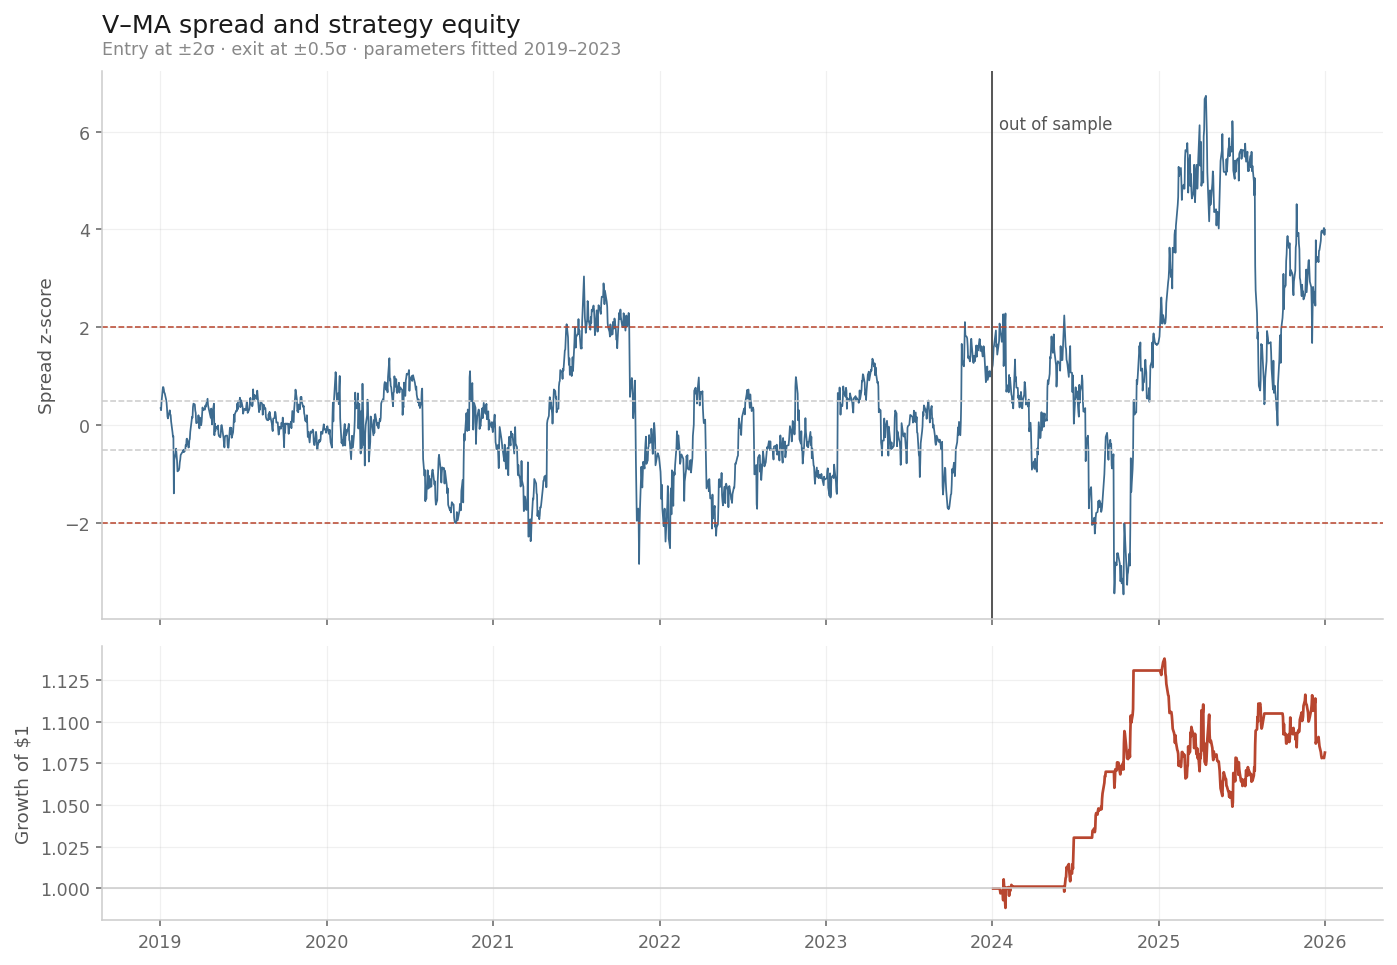

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 1, figsize=(10, 7), dpi=140, sharex=True,
                       gridspec_kw={"height_ratios": [2, 1]})

ax[0].plot(zscore.index, zscore.values, color="#3d6b8f", linewidth=0.9)
for lvl, c in [(2, "#b8462f"), (-2, "#b8462f"), (0.5, "#ccc"), (-0.5, "#ccc")]:
    ax[0].axhline(lvl, color=c, linewidth=0.8, linestyle="--")
ax[0].axvline(pd.Timestamp("2024-01-01"), color="#555", linewidth=1)
ax[0].text(pd.Timestamp("2024-01-15"), zscore.max()*0.9, "out of sample",
           fontsize=8.5, color="#555")
ax[0].set_ylabel("Spread z-score", fontsize=9.5, color="#555")
ax[0].set_title("V–MA spread and strategy equity", fontsize=13, loc="left", pad=20, color="#1a1a1a")
ax[0].text(0, 1.03, "Entry at ±2σ · exit at ±0.5σ · parameters fitted 2019–2023",
           transform=ax[0].transAxes, fontsize=9, color="#888")

ax[1].plot(equity.index, equity.values, color="#b8462f", linewidth=1.4)
ax[1].axhline(1, color="#ccc", linewidth=0.8)
ax[1].set_ylabel("Growth of $1", fontsize=9.5, color="#555")

for a in ax:
    a.grid(alpha=0.18, linewidth=0.6); a.set_axisbelow(True)
    a.tick_params(labelsize=9, colors="#666", length=3)
    for s in ("top", "right"): a.spines[s].set_visible(False)
    for s in ("left", "bottom"): a.spines[s].set_color("#ccc"); a.spines[s].set_linewidth(0.8)
plt.tight_layout(); plt.show()